In [6]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web

# Confirm you're using the right Python
print(f"Python: {sys.executable}")
print("All imports successful ✓")

Python: c:\Users\Kartik BADESARA\OneDrive\Desktop\My Project\.venv\Scripts\python.exe
All imports successful ✓


In [7]:
DATA_PATH = '../data/fred_data.csv'

if not os.path.exists(DATA_PATH):
    print("Downloading from FRED...")
    df = web.DataReader(
        ['GDPC1',      # US Real GDP (quarterly)
         'CPIAUCSL',   # US CPI Inflation (monthly)
         'UNRATE',     # US Unemployment Rate (monthly)
         'FEDFUNDS'],  # Federal Funds Rate (monthly)
        'fred',
        '2000-01-01',
        '2024-12-31'
    )
    df.to_csv(DATA_PATH)
    print(f"Saved to {DATA_PATH} ✓")
else:
    print("Loading from local file...")
    df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)

print(f"\nShape: {df.shape}")
print(f"Date range: {df.index[0].date()} → {df.index[-1].date()}")
df.head()

Loading from local file...

Shape: (300, 4)
Date range: 2000-01-01 → 2024-12-01


,GDPC1,CPIAUCSL,UNRATE,FEDFUNDS
DATE,,,,
2000-01-01,13878.147,169.3,4.0,5.45
2000-02-01,NaN,170.0,4.1,5.73
2000-03-01,NaN,171.0,4.0,5.85
2000-04-01,14130.908,170.9,3.8,6.02
2000-05-01,NaN,171.2,4.0,6.27


In [8]:
# Convert everything to quarterly by taking the last value in each quarter
df_q = df.resample('QE').last()

# Rename columns for readability
df_q.columns = ['Real_GDP', 'CPI', 'Unemployment', 'Fed_Funds_Rate']

# Drop rows where all values are missing
df_q.dropna(how='all', inplace=True)

print(f"Quarterly data shape: {df_q.shape}")
df_q.head(8)

Quarterly data shape: (100, 4)


,Real_GDP,CPI,Unemployment,Fed_Funds_Rate
DATE,,,,
2000-03-31,13878.147,171.0,4.0,5.85
2000-06-30,14130.908,172.2,4.0,6.53
2000-09-30,14145.312,173.6,3.9,6.52
2000-12-31,14229.765,174.6,3.9,6.40
2001-03-31,14183.120,176.1,4.3,5.31
2001-06-30,14271.694,177.7,4.5,3.97
2001-09-30,14214.516,178.1,5.0,3.07
2001-12-31,14253.574,177.4,5.7,1.82


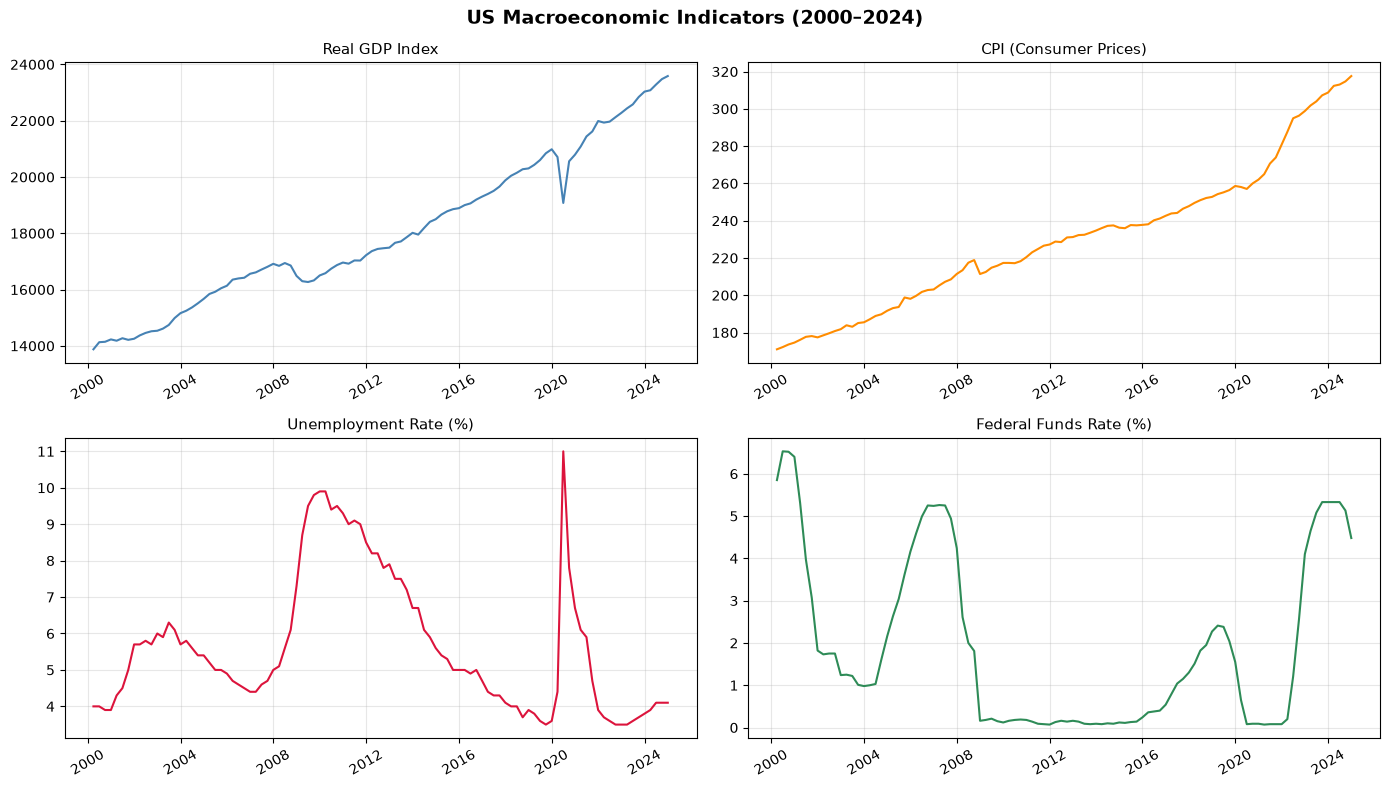

Chart saved to outputs/ ✓


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('US Macroeconomic Indicators (2000–2024)', fontsize=14, fontweight='bold')

series_info = [
    ('Real_GDP',       'Real GDP Index',          'steelblue'),
    ('CPI',            'CPI (Consumer Prices)',    'darkorange'),
    ('Unemployment',   'Unemployment Rate (%)',    'crimson'),
    ('Fed_Funds_Rate', 'Federal Funds Rate (%)',   'seagreen'),
]

for ax, (col, title, color) in zip(axes.flatten(), series_info):
    ax.plot(df_q.index, df_q[col], color=color, linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/macro_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs/ ✓")

In [10]:
# Use Real GDP for our first forecast
series = df_q['Real_GDP'].dropna()

# Train-test split: train on 2000–2019, test on 2020–2024
train = series[series.index < '2020-01-01']
test  = series[series.index >= '2020-01-01']

print(f"Train: {len(train)} quarters ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test:  {len(test)} quarters  ({test.index[0].date()} → {test.index[-1].date()})")

# Random Walk forecast: predict = last known value
rw_forecast = pd.Series(
    [train.iloc[-1]] * len(test),
    index=test.index
)

# Measure error
errors = test - rw_forecast
rmse_rw = np.sqrt(np.mean(errors**2))

print(f"\nRandom Walk RMSE: {rmse_rw:.2f}")
print("(This is the benchmark — your model must beat this)")

Train: 80 quarters (2000-03-31 → 2019-12-31)
Test:  20 quarters  (2020-03-31 → 2024-12-31)

Random Walk RMSE: 1505.98
(This is the benchmark — your model must beat this)


In [11]:
from statsmodels.tsa.ar_model import AutoReg

def backtest_ar(series, train_end, lags=2):
    """
    Expanding window backtest.
    Trains on all data up to each point, forecasts one step ahead.
    """
    actuals   = []
    forecasts = []
    dates     = []

    for i in range(train_end, len(series)):
        train_window = series.iloc[:i]
        model  = AutoReg(train_window, lags=lags, old_names=False).fit()
        fc     = model.forecast(steps=1)

        actuals.append(series.iloc[i])
        forecasts.append(fc.iloc[0])
        dates.append(series.index[i])

    return pd.Series(actuals, index=dates), pd.Series(forecasts, index=dates)


# Run backtest
train_end = len(train)
actuals, ar_forecast = backtest_ar(series, train_end, lags=4)

# RMSE
rmse_ar = np.sqrt(np.mean((actuals - ar_forecast)**2))

print(f"Random Walk RMSE : {rmse_rw:.2f}")
print(f"AR(4) Model RMSE : {rmse_ar:.2f}")

improvement = ((rmse_rw - rmse_ar) / rmse_rw) * 100
print(f"\nAR model is {improvement:.1f}% {'better' if improvement > 0 else 'worse'} than Random Walk")

Random Walk RMSE : 1505.98
AR(4) Model RMSE : 896.20

AR model is 40.5% better than Random Walk


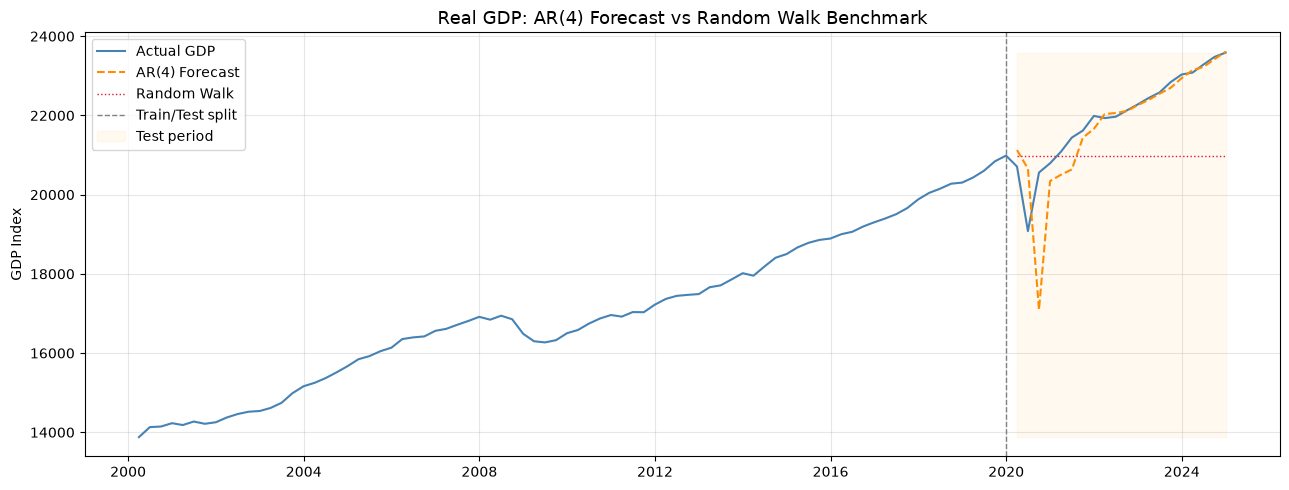

Chart saved to outputs/ ✓


In [12]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(series.index, series,         label='Actual GDP',         color='steelblue',  linewidth=1.5)
ax.plot(ar_forecast.index, ar_forecast, label='AR(4) Forecast',   color='darkorange', linewidth=1.5, linestyle='--')
ax.plot(rw_forecast.index, rw_forecast, label='Random Walk',      color='crimson',    linewidth=1,   linestyle=':')

ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1, label='Train/Test split')
ax.fill_betweenx([series.min(), series.max()],
                 test.index[0], test.index[-1],
                 alpha=0.06, color='orange', label='Test period')

ax.set_title('Real GDP: AR(4) Forecast vs Random Walk Benchmark', fontsize=13)
ax.set_ylabel('GDP Index')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs/ ✓")

In [13]:
results = pd.DataFrame({
    'Model':         ['Random Walk', 'AR(4)'],
    'RMSE':          [round(rmse_rw, 2), round(rmse_ar, 2)],
    'Test quarters': [len(test), len(actuals)],
    'Beats baseline':['-', '✓' if rmse_ar < rmse_rw else '✗'],
})

print("=" * 45)
print("  MODEL COMPARISON RESULTS")
print("=" * 45)
print(results.to_string(index=False))
print("=" * 45)

  MODEL COMPARISON RESULTS
      Model    RMSE  Test quarters Beats baseline
Random Walk 1505.98             20              -
      AR(4)  896.20             20              ✓


In [14]:
from statsmodels.tsa.api import VAR

# Use the quarterly dataframe you already built (df_q)
# Drop any remaining NaNs first
var_data = df_q.dropna()

# Fit the VAR model
model = VAR(var_data)
results = model.fit(maxlags=4, ic='aic')  # AIC auto-selects the best lag order

print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 13, Jul, 2026
Time:                     13:50:43
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    8.13359
Nobs:                     98.0000    HQIC:                   7.56810
Log likelihood:          -872.240    FPE:                    1320.92
AIC:                      7.18401    Det(Omega_mle):         929.495
--------------------------------------------------------------------
Results for equation Real_GDP
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                  -401.276720       412.102359           -0.974           0.330
L1.Real_GDP               1.324102         0.234556            5.645           0.000
L1.CPI                    7.943678       

In [15]:
# Forecast 8 quarters ahead (2 years)
lag_order = results.k_ar
forecast_input = var_data.values[-lag_order:]

forecast = results.forecast(forecast_input, steps=8)
forecast_df = pd.DataFrame(
    forecast,
    columns=var_data.columns,
    index=pd.date_range(var_data.index[-1], periods=8, freq='QE')
)

print(forecast_df.round(2))

            Real_GDP     CPI  Unemployment  Fed_Funds_Rate
2024-12-31  23593.64  320.39          4.66            3.90
2025-03-31  23695.11  322.97          4.98            3.44
2025-06-30  23799.94  325.40          5.21            3.07
2025-09-30  23909.22  327.76          5.42            2.81
2025-12-31  24033.90  330.07          5.56            2.63
2026-03-31  24168.59  332.35          5.66            2.52
2026-06-30  24311.14  334.64          5.72            2.47
2026-09-30  24460.55  336.95          5.75            2.46


In [16]:
import wbdata
import pandas as pd

india_indicators = {
    'NY.GDP.MKTP.KD.ZG': 'GDP_Growth',
    'FP.CPI.TOTL.ZG':    'Inflation',
    'SL.UEM.TOTL.ZS':    'Unemployment',
    'BN.CAB.XOKA.GD.ZS': 'Current_Account',
    'GC.DOD.TOTL.GD.ZS': 'Govt_Debt',
    'NE.GDI.TOTL.ZS':    'Investment',
}

india_df = wbdata.get_dataframe(
    india_indicators,
    country='IND'
)

india_df.index = pd.to_datetime(india_df.index)
india_df = india_df.sort_index()

print(india_df.tail(6))

            GDP_Growth  Inflation  Unemployment  Current_Account  Govt_Debt  \
date                                                                          
2020-01-01   -5.777725   6.623437         7.859         1.223621        NaN   
2021-01-01    9.689592   5.131407         6.380        -1.055242        NaN   
2022-01-01    7.609365   6.699034         4.822        -2.432383        NaN   
2023-01-01    7.210225   5.649143         4.172        -0.912778        NaN   
2024-01-01    7.099279   4.953036         4.173        -0.851290        NaN   
2025-01-01    7.566662   2.398850         4.219        -0.416854        NaN   

            Investment  
date                    
2020-01-01   28.922384  
2021-01-01   32.115822  
2022-01-01   34.411796  
2023-01-01   34.504684  
2024-01-01   34.345906  
2025-01-01   34.603005  


In [19]:
# Resample World Bank annual data to quarterly
india_annual = india_df.resample('YE').last()
india_quarterly = india_annual.resample('QE').ffill()

# Add 'India_' prefix to ALL World Bank columns to avoid name clashes
india_quarterly.columns = ['India_' + col for col in india_quarterly.columns]

# Now merge safely — no overlapping column names
combined = df_q.join(india_quarterly, how='left')

print(f"Combined shape: {combined.shape}")
print(f"Columns: {list(combined.columns)}")

combined.to_csv('../data/combined_macro_data.csv')
print("Saved combined dataset ✓")

Combined shape: (100, 10)
Columns: ['Real_GDP', 'CPI', 'Unemployment', 'Fed_Funds_Rate', 'India_GDP_Growth', 'India_Inflation', 'India_Unemployment', 'India_Current_Account', 'India_Govt_Debt', 'India_Investment']
Saved combined dataset ✓


In [20]:
# Use your combined dataframe — US variables have complete quarterly data
# Start with the 4 core US variables (complete, no gaps)
var_data = combined[['Real_GDP', 'CPI', 'Unemployment', 'Fed_Funds_Rate']].dropna()

# VAR requires stationary data — take percentage change (growth rates)
var_stationary = var_data.pct_change().dropna() * 100

print(f"VAR data shape: {var_stationary.shape}")
print(f"Date range: {var_stationary.index[0].date()} → {var_stationary.index[-1].date()}")
var_stationary.tail(4)

VAR data shape: (99, 4)
Date range: 2000-06-30 → 2024-12-31


,Real_GDP,CPI,Unemployment,Fed_Funds_Rate
DATE,,,,
2024-03-31,0.209861,1.167321,2.631579,0.000000
2024-06-30,0.885486,0.223791,5.128205,0.000000
2024-09-30,0.824778,0.539221,0.000000,-3.752345
2024-12-31,0.459875,0.912522,0.000000,-12.670565


In [21]:
from statsmodels.tsa.api import VAR

# Train on pre-2020 data, test on 2020 onwards
var_train = var_stationary[var_stationary.index < '2020-01-01']
var_test  = var_stationary[var_stationary.index >= '2020-01-01']

print(f"Train: {len(var_train)} quarters")
print(f"Test:  {len(var_test)} quarters")

# Fit VAR — AIC automatically selects the best number of lags
model   = VAR(var_train)
results = model.fit(maxlags=8, ic='aic')

print(f"\nSelected lag order: {results.k_ar}")
print(results.summary())

Train: 79 quarters
Test:  20 quarters

Selected lag order: 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 13, Jul, 2026
Time:                     13:59:47
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    7.48596
Nobs:                     78.0000    HQIC:                   7.12358
Log likelihood:          -691.094    FPE:                    974.945
AIC:                      6.88168    Det(Omega_mle):         760.407
--------------------------------------------------------------------
Results for equation Real_GDP
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.437857         0.097530            4.489           0.000
L1.Real_GDP               0.201628         0.141563            1.

In [22]:
# Get the last k_ar rows of training data as input to the forecast
lag_order     = results.k_ar
forecast_input = var_train.values[-lag_order:]

# Forecast 8 quarters ahead (2 years)
forecast_vals = results.forecast(forecast_input, steps=len(var_test))

forecast_df = pd.DataFrame(
    forecast_vals,
    index=var_test.index,
    columns=var_stationary.columns
)

print("VAR Forecast (quarterly % change):")
print(forecast_df.round(3))

VAR Forecast (quarterly % change):
            Real_GDP    CPI  Unemployment  Fed_Funds_Rate
DATE                                                     
2020-03-31     0.394  0.602         1.565         -10.521
2020-06-30     0.413  0.532         1.391          -3.922
2020-09-30     0.441  0.526         1.000          -1.187
2020-12-31     0.461  0.523         0.704           0.116
2021-03-31     0.475  0.523         0.511           0.864
2021-06-30     0.483  0.523         0.390           1.313
2021-09-30     0.489  0.523         0.314           1.588
2021-12-31     0.492  0.523         0.267           1.758
2022-03-31     0.494  0.523         0.238           1.864
2022-06-30     0.495  0.523         0.220           1.929
2022-09-30     0.496  0.523         0.208           1.969
2022-12-31     0.497  0.523         0.201           1.994
2023-03-31     0.497  0.523         0.197           2.010
2023-06-30     0.497  0.523         0.194           2.019
2023-09-30     0.497  0.523         0

In [23]:
from sklearn.metrics import mean_squared_error

print("=" * 45)
print("  VAR MODEL — RMSE BY VARIABLE")
print("=" * 45)

for col in var_stationary.columns:
    actual   = var_test[col].values
    predicted = forecast_df[col].values

    # Align lengths in case of mismatch
    min_len  = min(len(actual), len(predicted))
    rmse_var = np.sqrt(mean_squared_error(actual[:min_len], predicted[:min_len]))

    # Random walk benchmark for same variable
    rw_pred  = np.zeros(min_len)   # RW in differenced space = predict 0 change
    rmse_rw  = np.sqrt(mean_squared_error(actual[:min_len], rw_pred))

    better = "✓ beats RW" if rmse_var < rmse_rw else "✗ worse than RW"
    print(f"{col:<20} VAR RMSE: {rmse_var:.4f}   RW RMSE: {rmse_rw:.4f}   {better}")

print("=" * 45)

  VAR MODEL — RMSE BY VARIABLE
Real_GDP             VAR RMSE: 2.5629   RW RMSE: 2.6415   ✓ beats RW
CPI                  VAR RMSE: 0.9615   RW RMSE: 1.3144   ✓ beats RW
Unemployment         VAR RMSE: 35.0438   RW RMSE: 35.3066   ✓ beats RW
Fed_Funds_Rate       VAR RMSE: 122.6876   RW RMSE: 123.6874   ✓ beats RW


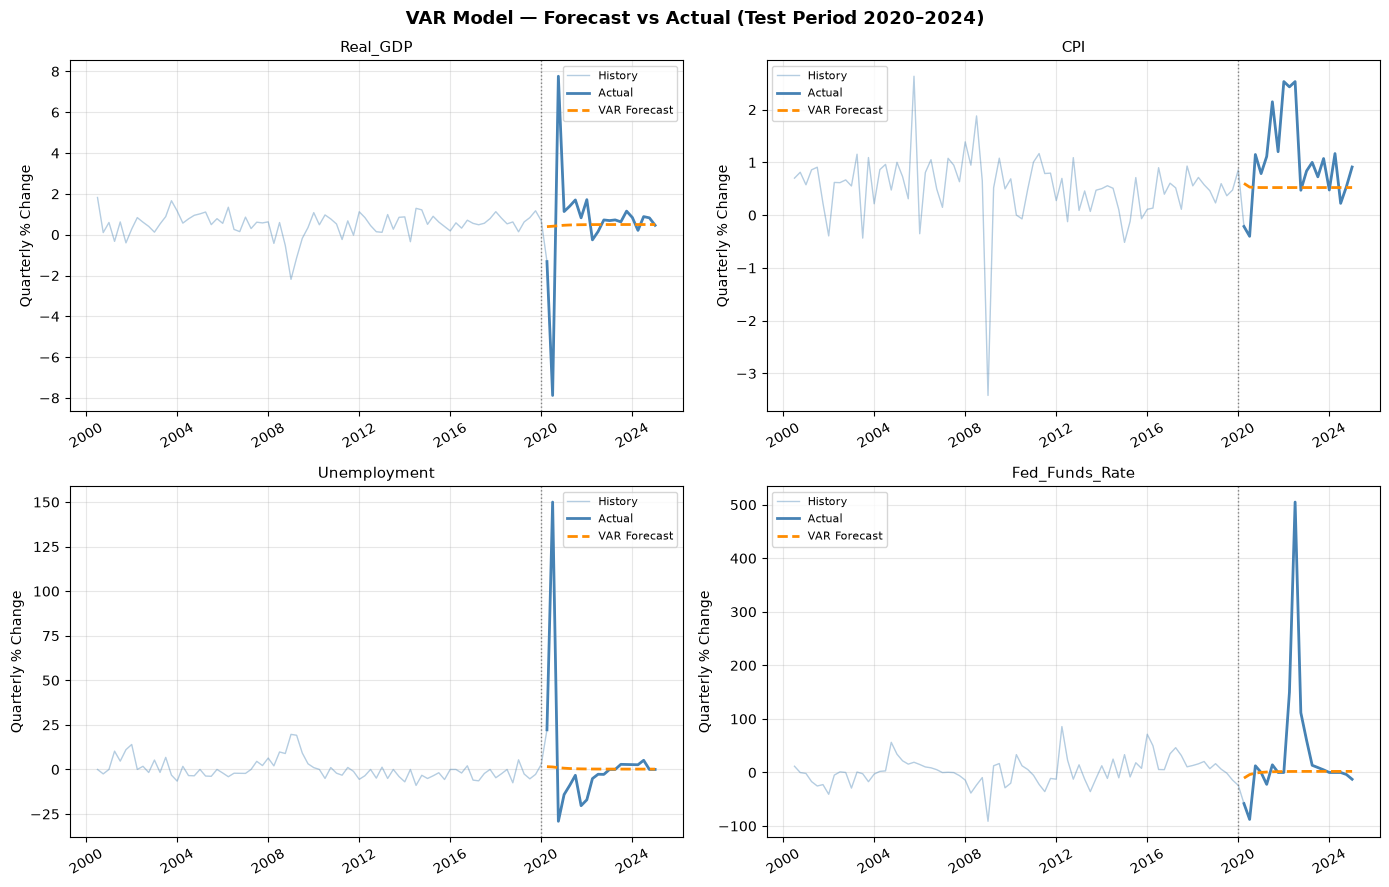

Chart saved to outputs/ ✓


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('VAR Model — Forecast vs Actual (Test Period 2020–2024)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), var_stationary.columns):
    # Plot full history lightly
    ax.plot(var_stationary.index, var_stationary[col],
            color='steelblue', linewidth=1, alpha=0.4, label='History')

    # Plot test actual
    ax.plot(var_test.index, var_test[col],
            color='steelblue', linewidth=2, label='Actual')

    # Plot VAR forecast
    ax.plot(forecast_df.index, forecast_df[col],
            color='darkorange', linewidth=2, linestyle='--', label='VAR Forecast')

    ax.axvline(x=var_train.index[-1], color='gray',
               linestyle=':', linewidth=1)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Quarterly % Change')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/var_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs/ ✓")

In [25]:
model_scores = []

for col in var_stationary.columns:
    actual    = var_test[col].values
    predicted = forecast_df[col].values
    min_len   = min(len(actual), len(predicted))

    rmse_var  = np.sqrt(mean_squared_error(actual[:min_len], predicted[:min_len]))
    rmse_rw   = np.sqrt(mean_squared_error(actual[:min_len], np.zeros(min_len)))

    model_scores.append({
        'Variable':      col,
        'RW RMSE':       round(rmse_rw, 4),
        'VAR RMSE':      round(rmse_var, 4),
        'Improvement %': round((rmse_rw - rmse_var) / rmse_rw * 100, 1)
    })

scores_df = pd.DataFrame(model_scores)
print(scores_df.to_string(index=False))

scores_df.to_csv('../outputs/model_comparison.csv', index=False)
print("\nSaved to outputs/model_comparison.csv ✓")

      Variable  RW RMSE  VAR RMSE  Improvement %
      Real_GDP   2.6415    2.5629            3.0
           CPI   1.3144    0.9615           26.8
  Unemployment  35.3066   35.0438            0.7
Fed_Funds_Rate 123.6874  122.6876            0.8

Saved to outputs/model_comparison.csv ✓
